In [162]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [11]:
df = pd.read_csv('CTG.csv')
df

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,Variab10.txt,12/1/1996,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,Fmcs_1.txt,5/3/1996,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,Fmcs_1.txt,5/3/1996,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,5/3/1996,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,5/3/1996,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2124,S8001045.dsp,6/6/1998,CTG2127.txt,1576.0,3049.0,140.0,140.0,1.0,0.0,9.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2125,S8001045.dsp,6/6/1998,CTG2128.txt,2796.0,3415.0,142.0,142.0,1.0,1.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# preprocessing

In [19]:
#NSP is target var
df.columns

Index(['FileName', 'Date', 'SegFile', 'b', 'e', 'LBE', 'LB', 'AC', 'FM', 'UC',
       'ASTV', 'MSTV', 'ALTV', 'MLTV', 'DL', 'DS', 'DP', 'DR', 'Width', 'Min',
       'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance',
       'Tendency', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP',
       'CLASS', 'NSP'],
      dtype='object')

In [21]:

# drop cols:
cols =['FileName', 'Date','SegFile', 'b', 'e','A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP']
df.drop(columns=cols, inplace=True)


In [25]:
df.columns

Index(['LBE', 'LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'DL',
       'DS', 'DP', 'DR', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode',
       'Mean', 'Median', 'Variance', 'Tendency', 'CLASS', 'NSP'],
      dtype='object')

In [34]:
df.isna().sum()

LBE         3
LB          3
AC          3
FM          2
UC          2
ASTV        2
MSTV        2
ALTV        2
MLTV        2
DL          1
DS          1
DP          1
DR          1
Width       3
Min         3
Max         3
Nmax        3
Nzeros      3
Mode        3
Mean        3
Median      3
Variance    3
Tendency    3
CLASS       3
NSP         3
dtype: int64

df.dropna(inplace=True)
df.isna().sum()

In [166]:
X = df.drop('NSP',axis = 1)
y = df['NSP']
lc = LabelEncoder()
y = lc.fit_transform(y)
sd = StandardScaler()
x_scaled = sd.fit_transform(X)


In [168]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled,y, train_size=0.8)

In [170]:
print("X train shape: ",X_train.shape)
print("y train shape: ",y_train.shape)
print("X test shape: ",X_test.shape)
print("y test shape: ",y_test.shape)

X train shape:  (1700, 24)
y train shape:  (1700,)
X test shape:  (426, 24)
y test shape:  (426,)


# Model creation:

In [173]:
X_train.shape[1]

24

In [175]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(30, activation='relu',input_shape = (X_train.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(15, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(7, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation='softmax')
])
model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                │ (None, 30)             │           750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 7)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 3)              │            24 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,351 (5.28 KB)

 Trainable params: 1,351 (5.28 KB)

 Non-trainable params: 0 (0.00 B)

In [177]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [179]:
history = model.fit(X_train,y=y_train,batch_size=32,
    epochs=100,validation_split=0.2)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6694 - loss: 0.8760 - val_accuracy: 0.7794 - val_loss: 0.6216
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step - accuracy: 0.7761 - loss: 0.6472 - val_accuracy: 0.7824 - val_loss: 0.4936
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - accuracy: 0.7805 - loss: 0.6248 - val_accuracy: 0.8294 - val_loss: 0.4153
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step - accuracy: 0.8121 - loss: 0.5038 - val_accuracy: 0.8647 - val_loss: 0.3598
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - accuracy: 0.8278 - loss: 0.4498 - val_accuracy: 0.8794 - val_loss: 0.3307
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step - accuracy: 0.8393 - loss: 0.4172 - val_accuracy: 0.8971 - val_loss: 0.3001
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step - accuracy: 0.8686 - loss: 0.3648 - val_accuracy: 0.9059 - val_loss: 0.2750
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step - accuracy: 0.8894 - loss: 0.3507 - val_accura

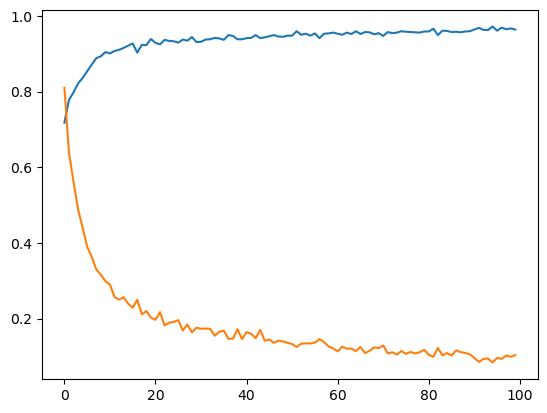

In [194]:
# ploting the loss and acc

plt.plot(history.epoch,history.history['accuracy'])
plt.plot(history.epoch,history.history['loss'])
plt.show()

# Relu and leaky relu

In [150]:
# 4. ReLU
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

#5. leaky_relu
def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)


z = np.linspace(-10, 10, 100)  

In [160]:
x_leaky = leaky_relu(z)
y_leaky = leaky_relu_derivative(z)
x_relu = relu(z)
y_relu = relu_derivative(z)


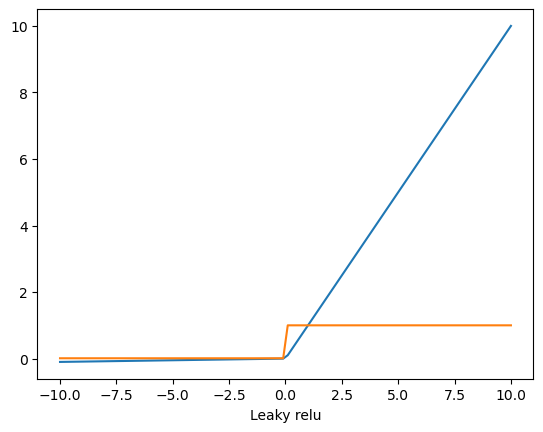

In [181]:
plt.plot(z,x_leaky) 
plt.plot(z,y_leaky)
plt.xlabel('Leaky relu')
plt.show()

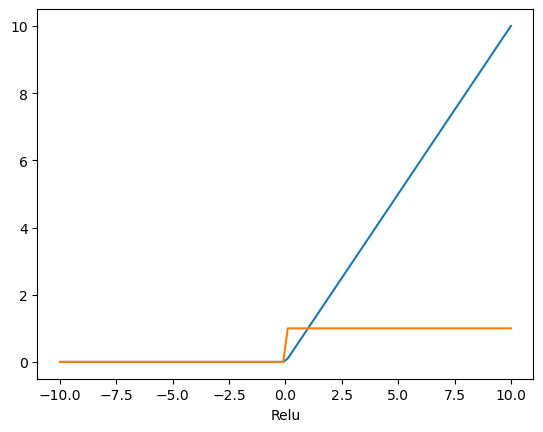

In [183]:
plt.plot(z,x_relu)
plt.plot(z,y_relu)
plt.xlabel('Relu')
plt.show()